# Day 07：恒等映射的完美 —— 当 F(x) = 0 就是最好的答案> 🌉 第八周 · ResNet 的深度 · 第 7 天昨天我们从梯度的角度理解了残差连接的有效性。今天，我们要深入探讨残差学习中一个极其优雅的性质——**恒等映射（Identity Mapping）**。这个性质是残差学习的灵魂：**当网络不需要做任何修改时，它只需要让 F(x) = 0**。这听起来简单，但它蕴含着深刻的智慧。让我们用代码和直觉来彻底理解它。**今天的任务**：1. 理解为什么 F(x) = 0 是残差块的"完美休息状态"2. 用代码验证：残差块在训练过程中 F(x) 如何趋向于零3. 理解"恒等映射假设"对深层网络的意义---

## 1. 历史剧场：何恺明的核心洞察在 ResNet 论文中，何恺明提出了一个关键的观察：> 如果一个浅层网络已经能很好地完成任务，那么在它后面添加更多层时，这些新层至少应该能学习到**恒等映射（Identity Mapping）**——即输出等于输入。换句话说：- 浅层网络学到了不错的特征表示 H(x)- 在它后面加一层，如果这一层什么都不做（H(x) = x），那么深层网络至少不会比浅层差- 但普通网络很难学到精确的恒等映射- **残差网络只需要学 F(x) = 0 就等价于恒等映射——这太容易了！**这就是残差学习的本质：**把"学恒等映射"变成"学零"。**---

## 2. 生活隐喻：三种"不做事情"的方式想象你的老板让你修改一份文档：### 方式一：从头写一遍（普通网络的困境）老板说："请重写这份文档。"你不得不重新写一遍一模一样的内容。但无论你多努力，总会有细微差异——而且这非常浪费时间。### 方式二：直接提交原稿（理想情况）你说："这份文档不需要修改，我直接提交原稿。"这是最完美的方案——但普通网络没有这个选项。### 方式三：写"无修改意见"（残差网络的方案）你在文档上标注："无修改"（F(x) = 0），然后输出 = 原稿 + 无修改 = 原稿。这就是残差学习的精髓：**"不做事情"变得极其容易——只需要输出零。**---

<p align="center">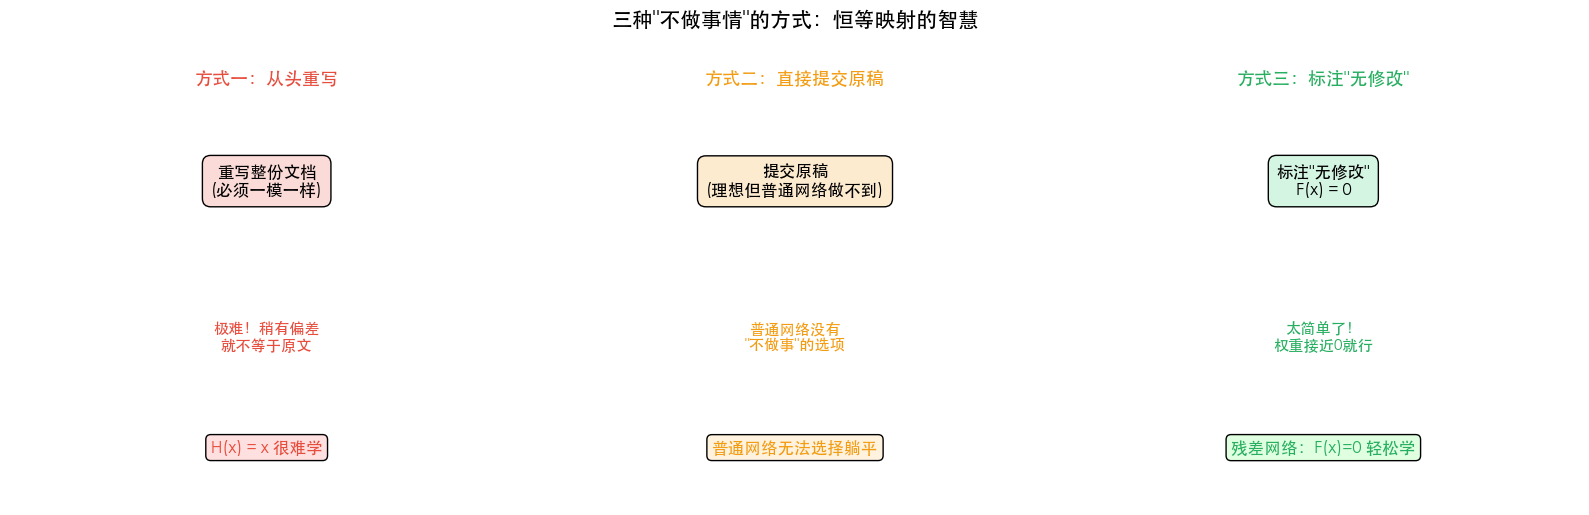</p>*恒等映射三种方式对比图*

## 3. 几何直觉：F(x) = 0 是最平坦的山谷从优化的角度来看，残差块有一个极其优美的性质：

<p align="center">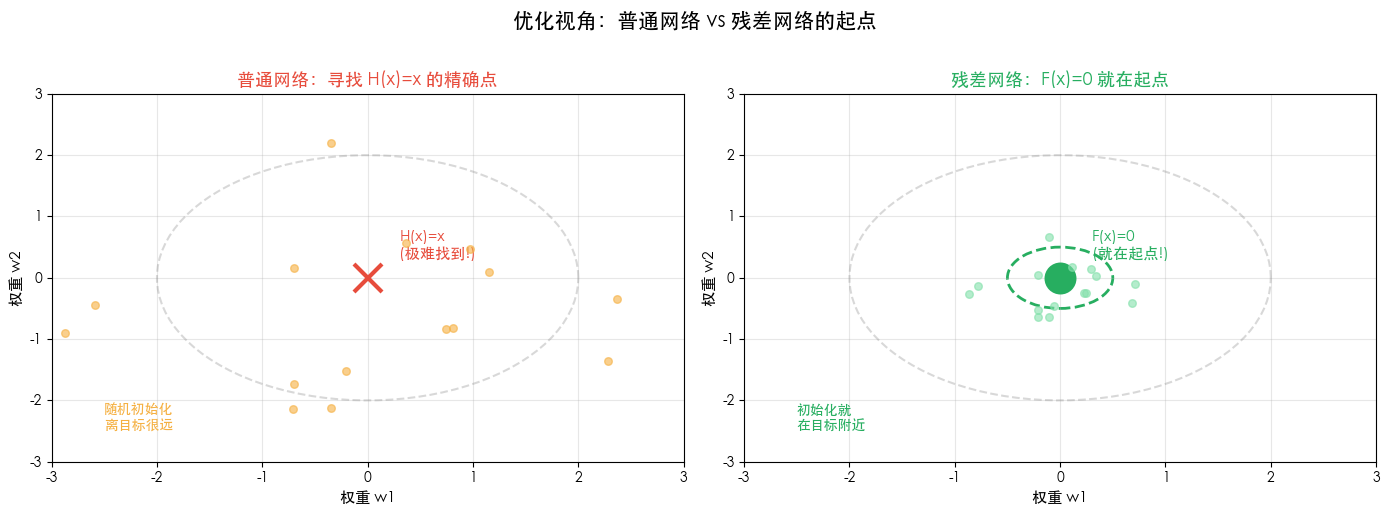</p>*恒等映射优化起点对比图*

目标函数: L(F(x) + x, y)如果最优解就是 y ≈ x（即输入已经是好的特征），那么：  F(x) = 0 时，L(0 + x, y) = L(x, y) 已经是最小值

这意味着：**F(x) = 0 是损失函数的一个局部最小值点**——而且是很容易找到的那个！对于普通网络来说，要找到"恰好输出等于输入"的权重组合，就像要在茫茫大海中找到一个特定的坐标点——几乎不可能。但对于残差网络来说，F(x) = 0 对应的是所有权重都接近零的状态——这正是权重初始化时的状态！网络一开始就在"好答案"附近。---

## 4. 代码实验室：追踪 F(x) 的变化### 4.1 准备工作

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.2 构建可检查残差的残差块

In [ ]:
class InspectableResidualBlock(nn.Module):    """可以检查内部残差 F(x) 大小的残差块"""    def __init__(self, hidden_size):        super().__init__()        self.layer1 = nn.Linear(hidden_size, hidden_size)        self.bn1 = nn.BatchNorm1d(hidden_size)        self.layer2 = nn.Linear(hidden_size, hidden_size)        self.bn2 = nn.BatchNorm1d(hidden_size)    def forward(self, x):        identity = x        out = F.relu(self.bn1(self.layer1(x)))        out = self.bn2(self.layer2(out))        residual_value = out.detach().clone()        out = out + identity        out = F.relu(out)        return out, residual_valueclass InspectableResNet(nn.Module):    """可检查每层残差值的残差网络"""    def __init__(self, num_blocks=10, hidden_size=32):        super().__init__()        self.input_layer = nn.Linear(2, hidden_size)        self.blocks = nn.ModuleList([InspectableResidualBlock(hidden_size) for _ in range(num_blocks)])        self.output_layer = nn.Linear(hidden_size, 1)        self.sigmoid = nn.Sigmoid()        self.residual_history = []    def forward(self, x):        x = F.relu(self.input_layer(x))        residuals_at_this_step = []        for block in self.blocks:            x, residual = block(x)            residuals_at_this_step.append(residual.norm().item())        x = self.sigmoid(self.output_layer(x))        if self.training:            self.residual_history.append(residuals_at_this_step)        return x

### 4.3 训练并追踪残差

In [ ]:
def make_spiral_data(n_samples=300, noise=0.25):    np.random.seed(42)    n = n_samples // 2    theta_class0 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise    theta_class1 = np.linspace(0, 2 * np.pi, n) + np.random.randn(n) * noise + np.pi    r_class0 = theta_class0 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    r_class1 = theta_class1 / (2 * np.pi) + np.random.randn(n) * noise * 0.3    x_class0 = np.column_stack([r_class0 * np.cos(theta_class0), r_class0 * np.sin(theta_class0)])    x_class1 = np.column_stack([r_class1 * np.cos(theta_class1), r_class1 * np.sin(theta_class1)])    X = np.vstack([x_class0, x_class1]).astype(np.float32)    y = np.concatenate([np.zeros(n), np.ones(n)]).astype(np.float32)    return torch.tensor(X), torch.tensor(y).unsqueeze(1)X_data, y_data = make_spiral_data()torch.manual_seed(42)inspect_net = InspectableResNet(num_blocks=12)optimizer = torch.optim.Adam(inspect_net.parameters(), lr=0.01)loss_fn = nn.BCELoss()epochs = 400for epoch in range(epochs):    inspect_net.train()    pred = inspect_net(X_data)    loss = loss_fn(pred, y_data)    optimizer.zero_grad()    loss.backward()    optimizer.step()residual_array = np.array(inspect_net.residual_history)print(f"训练完成！收集了 {len(residual_array)} 步的残差数据")

### 4.4 可视化：F(x) 随训练的变化

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].imshow(residual_array.T, aspect='auto', cmap='coolwarm',                interpolation='nearest')axes[0].set_xlabel('训练步骤', fontsize=12)axes[0].set_ylabel('Block 编号', fontsize=12)axes[0].set_title('各 Block 残差 F(x) 范数随训练变化', fontsize=14)plt.colorbar(axes[0].images[0], ax=axes[0], label='||F(x)||')sample_steps = [0, len(residual_array)//4, len(residual_array)//2,                3*len(residual_array)//4, len(residual_array)-1]colors = plt.cm.viridis(np.linspace(0, 1, len(sample_steps)))for i, step in enumerate(sample_steps):    axes[1].plot(range(len(residual_array[step])), residual_array[step],                 'o-', color=colors[i], alpha=0.8, label=f'Step {step}')axes[1].set_xlabel('Block 编号', fontsize=12)axes[1].set_ylabel('残差 ||F(x)||', fontsize=12)axes[1].set_title('不同训练阶段各 Block 的残差大小', fontsize=14)axes[1].legend(fontsize=10, loc='upper right')axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **热力图**：随着训练进行，某些 Block 的残差变小了（颜色变冷）- **曲线图**：早期（紫色）残差较大，后期（黄色/绿色）部分 Block 的残差趋近于零这说明什么？说明部分 Block 学会了"躺平"——F(x) → 0，让信息通过近道直接传递过去。---

## 5. 关键实验：哪些 Block "躺平"了？

In [ ]:
initial_residuals = residual_array[0]final_residuals = residual_array[-1]fig, ax = plt.subplots(1, 1, figsize=(10, 6))x_pos = np.arange(len(initial_residuals))width = 0.35bars1 = ax.bar(x_pos - width/2, initial_residuals, width,               label='初始 (Step 0)', color='#e74c3c', alpha=0.8)bars2 = ax.bar(x_pos + width/2, final_residuals, width,               label='最终 (Step 最后)', color='#2ecc71', alpha=0.8)ax.set_xlabel('Block 编号', fontsize=14)ax.set_ylabel('残差范数 ||F(x)||', fontsize=14)ax.set_title('哪些 Block 学会了"躺平"？', fontsize=16)ax.legend(fontsize=12)ax.grid(True, alpha=0.3, axis='y')for bar, val in zip(bars2, final_residuals):    change = val - initial_residuals[bars2.index(bar)]    symbol = "↓ 躺平" if change < -0.5 else ("↑ 工作" if change > 0.5 else "~ 保持")    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,            f'{val:.1f}\n{symbol}', ha='center', fontsize=9)plt.tight_layout()plt.show()

### 解读你会发现：- 有些 Block 的残差显著减小（"躺平"）：它们决定让信息直接通过- 有些 Block 的残差保持或增大（"工作"）：它们在做有意义的特征变换- **每个 Block 自主选择"工作"还是"躺平"**——这就是残差学习的自适应能力---

## 6. 为什么"躺平"不是坏事？很多人担心：如果 Block 都"躺平"了（F(x) = 0），那深层网络不就退化成浅层网络了吗？答案是：**是的，但这恰恰是好事！**关键逻辑链：1. 如果浅层网络就能完成任务 → 深层网络的 Block 选择"躺平" → 效果等同于浅层网络 ✓2. 如果需要更深的特征 → 部分 Block 选择"工作"，部分"躺平" → 自动找到最优深度 ✓3. 无论哪种情况，**深层网络都不会比浅层更差** ✓这就是残差连接的终极保证：**深层 ≥ 浅层**。---

## 今日结语今天我们深入理解了残差学习中"恒等映射"的优雅：1. **F(x) = 0 是最简单的"不做事"方式**——比学精确的恒等映射容易得多2. **训练过程中，部分 Block 会自动学会"躺平"**——残差趋近于零3. **"躺平"不是坏事**——它保证了深层网络至少不比浅层差4. **每个 Block 自主选择**——该工作的 Block 工作，该躺平的 Block 躺平这种"自适应深度"的能力，是 ResNet 能够成功训练 152 层甚至更深网络的核心原因之一。明天，我们将从单个 Block 出发，学习如何把它们堆叠成完整的 ResNet 网络。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 写"无修改意见"而不是重写整份文档 | F(x) = 0 等价于恒等映射 || 文档已经很好了，不需要改 | 输入已经是好的特征，无需变换 || 从头重写很难做到一模一样 | 普通网络难以学到精确的恒等映射 || 标注"无修改"非常简单 | 残差网络只需让 F(x)=0 || 权重初始化时接近零 | 初始状态就在"好答案"附近 || F(x) = 0 是损失函数的局部最小值 | 最优化视角下的恒等映射 || 部分人工作，部分人摸鱼 | 部分Block工作，部分Block躺平 || "躺平"保证至少不比之前差 | 残差连接保证深层 ≥ 浅层 || 自动找到最优的工作分配 | 自适应深度（Adaptive Depth） |